<a href="https://colab.research.google.com/github/akash-dev0/ml-100days/blob/master/regression_metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [37]:
df = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv")



In [38]:
print(df.shape)
print(df.head())

(1338, 7)
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [39]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


In [40]:
print(df.describe())

               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


In [41]:
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


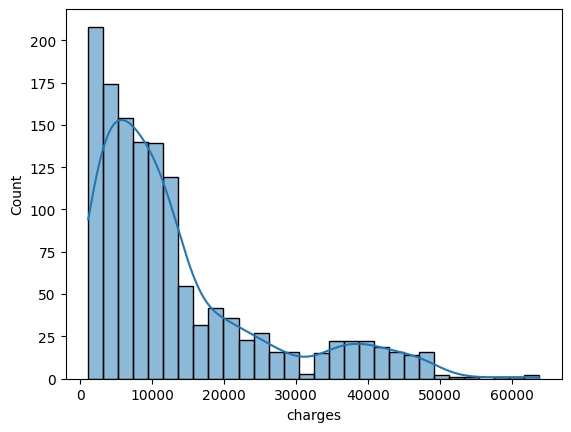

In [42]:
sns.histplot(df["charges"], bins = 30, kde = True)
plt.show()

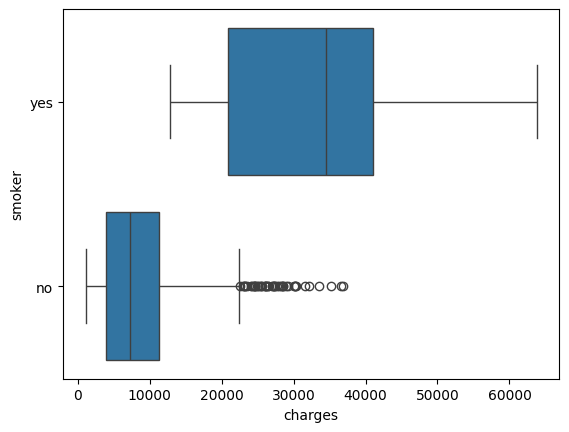

In [43]:
sns.boxplot(x="charges", y="smoker", data = df)
plt.show()

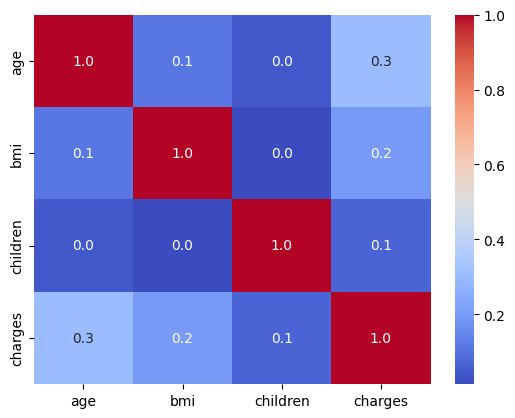

In [44]:
sns.heatmap(df.corr(numeric_only= True), annot=True, cmap="coolwarm", fmt=".1f")
plt.show()

In [45]:
# Encode categorical columns
df["sex"] = df["sex"].map({"male": 1, "female": 0})
df["smoker"] = df["smoker"].map({"yes": 1, "no": 0})
df = pd.get_dummies(df, columns=["region"], drop_first=True)

print(df.head())
print(df.columns)

   age  sex     bmi  children  smoker      charges  region_northwest  \
0   19    0  27.900         0       1  16884.92400             False   
1   18    1  33.770         1       0   1725.55230             False   
2   28    1  33.000         3       0   4449.46200             False   
3   33    1  22.705         0       0  21984.47061              True   
4   32    1  28.880         0       0   3866.85520              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='object')


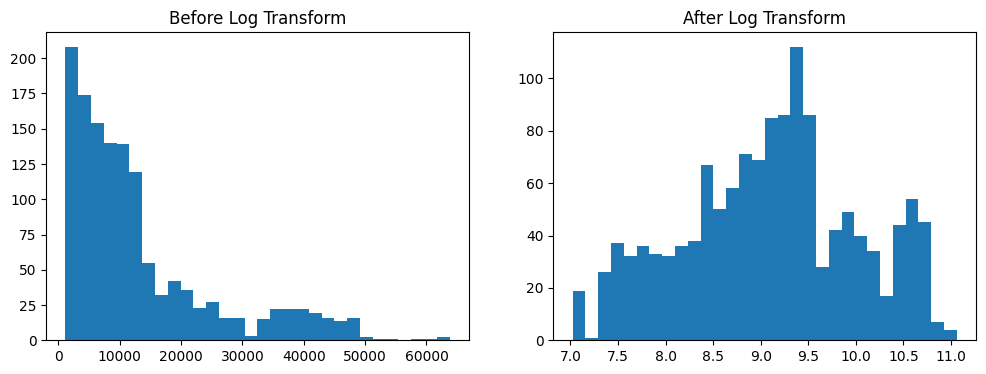

In [46]:
df["charges_log"] = np.log(df["charges"])

# Compare before and after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["charges"], bins=30)
axes[0].set_title("Before Log Transform")
axes[1].hist(df["charges_log"], bins=30)
axes[1].set_title("After Log Transform")
plt.show()

In [47]:
x = df[['age', 'sex', 'bmi', 'children', 'smoker',
       'region_northwest', 'region_southeast', 'region_southwest']]

In [48]:
y = df[['charges_log']]

In [49]:

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [52]:
model = LinearRegression()

In [53]:
model.fit(x_train, y_train)

LinearRegression()

In [54]:
y_pred = model.predict(x_test)

In [56]:
print("Actual :", y_test)
print("Predicted :", y_pred)


Actual :       charges_log
764      9.115488
887      8.570198
890     10.286400
1293     9.137973
259     10.426744
...           ...
109     10.759084
575      9.411066
535      8.710640
543     11.063045
846      9.197529

[268 rows x 1 columns]
Predicted : [[ 9.11460197]
 [ 8.63097424]
 [11.09890997]
 [ 9.11828346]
 [ 9.55198904]
 [ 8.68960332]
 [ 7.94673471]
 [ 9.62273203]
 [ 8.24029881]
 [ 9.2610713 ]
 [10.03761867]
 [ 8.92049933]
 [ 8.39820157]
 [10.81615193]
 [10.99879723]
 [10.71157421]
 [ 9.35358029]
 [10.66206064]
 [ 8.95943084]
 [10.37975511]
 [ 8.49278914]
 [ 8.95018237]
 [ 7.91347583]
 [ 8.34102567]
 [ 9.36191472]
 [ 9.33998206]
 [ 9.45580902]
 [ 8.60527649]
 [ 9.20247264]
 [ 7.86218361]
 [ 9.06181214]
 [ 9.37467675]
 [ 8.10359695]
 [ 8.56589491]
 [ 8.24020204]
 [ 9.05432162]
 [ 8.09436523]
 [ 8.89536488]
 [10.74294471]
 [10.19156291]
 [ 8.42558526]
 [ 8.18772342]
 [ 9.42079485]
 [ 9.28225507]
 [ 8.63705627]
 [ 9.33630301]
 [ 8.35128321]
 [ 8.38768321]
 [10.62664875]
 [ 8

In [58]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

n = len(y_test)
k = x_test.shape[1]
adj_r2 = 1 - (1-r2) * (n-1)/(n-k-1)


In [60]:
print(f"MAE:         {mae:.2f}")
print(f"MSE:         {mse:.2f}")
print(f"RMSE:        {rmse:.2f}")
print(f"R²:          {r2:.2f}")
print(f"Adjusted R²: {adj_r2:.2f}")

MAE:         0.27
MSE:         0.18
RMSE:        0.42
R²:          0.80
Adjusted R²: 0.80


In [61]:
# Convert predictions back to original scale
y_pred_actual = np.exp(y_pred)
y_test_actual = np.exp(y_test)

mae_actual = mean_absolute_error(y_test_actual, y_pred_actual)
print(f"MAE in actual dollars: ${mae_actual:.2f}")

MAE in actual dollars: $3888.77


In [63]:
#✅ Loaded real dataset (1338 rows)
#✅ Full EDA — distributions, boxplots, heatmap
#✅ Encoded categorical columns (sex, smoker, region)
#✅ Log transformation on skewed target
#✅ Train/Test split (80/20)
#✅ Linear Regression model
#✅ All 5 metrics — MAE, MSE, RMSE, R², Adjusted R²
#✅ Converted predictions back to real dollars